<a href="https://colab.research.google.com/github/druvetron/data-science-project/blob/main/FDS_G1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [7]:
file_path = '/content/drive/MyDrive/ColabFDS/UDPLag.csv'

# **Step_0 :Environment Setup and Data Loading**
First, we need to import the necessary libraries and load your dataset from Google Drive.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from mlxtend.frequent_patterns import apriori, association_rules
from scipy import stats
!pip install --upgrade jupyter_client

df = pd.read_csv(file_path)

print(df.head())
print(df.info())

/tmp/ipykernel_3135/2742711934.py:16: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


   Unnamed: 0                                 Flow ID   Source IP  \
0      186059   172.16.0.5-192.168.50.1-58445-4463-17  172.16.0.5   
1      135692   172.16.0.5-192.168.50.1-36908-9914-17  172.16.0.5   
2       33822  172.16.0.5-192.168.50.1-41727-32361-17  172.16.0.5   
3       24498   172.16.0.5-192.168.50.1-55447-5691-17  172.16.0.5   
4      117372  172.16.0.5-192.168.50.1-58794-56335-17  172.16.0.5   

    Source Port  Destination IP   Destination Port   Protocol  \
0         58445    192.168.50.1               4463         17   
1         36908    192.168.50.1               9914         17   
2         41727    192.168.50.1              32361         17   
3         55447    192.168.50.1               5691         17   
4         58794    192.168.50.1              56335         17   

                    Timestamp   Flow Duration   Total Fwd Packets  ...  \
0  2018-12-01 13:04:45.928673               1                   2  ...   
1  2018-12-01 13:04:45.928913               1 

# **Step_1: Data Reduction (PCA)**
**Process**: Uses PCA to compress 80+ redundant network features into a smaller, core set of composite variables.

**Result:** A leaner, faster dataset that retains $95\%$ of the original information while removing mathematical "noise."

In [9]:
# 1. Clean columns and handle Infinity/NaNs (prevents crashes)
df.columns = df.columns.str.strip()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# 2. Separate Target and grab only numeric features
# (PCA requires pure numbers, so we drop the string labels)
X = df.drop(columns=['Label']).select_dtypes(include=[np.number])
y = df['Label']

# 3. Data Reduction using PCA (keeps 95% of the information)
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_scaled)

print("Data Reduction Complete!")
print(f"Original features: {X.shape[1]} -> Reduced features: {X_reduced.shape[1]}")

Data Reduction Complete!
Original features: 82 -> Reduced features: 24


# **Step_3: Data Transformation (Scaling)**
**Process:** Squeezes all varying numeric ranges (like 0 to 1,000,000) into a uniform scale between 0 and 1.

**Result:** A level playing field where small and large values have equal weight, preventing the model from being biased by large numbers.

In [10]:
from sklearn.preprocessing import MinMaxScaler

# 1. Identify only the numeric columns (skipping the 'Label' column)
numeric_cols = df.drop(columns=['Label'], errors='ignore').select_dtypes(include=[np.number]).columns

# 2. Apply Min-Max Scaling
# This transforms all your numbers to a clean 0-1 range
scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Data Transformation Complete!")
# Show a preview of the transformed data
print(df[numeric_cols].head())

Data Transformation Complete!
   Unnamed: 0  Source Port  Destination Port  Protocol  Flow Duration  \
0    0.502043     0.891854          0.068101       1.0   0.000000e+00   
1    0.366137     0.563206          0.151278       1.0   0.000000e+00   
2    0.091262     0.636742          0.493797       1.0   8.333334e-09   
3    0.066103     0.846106          0.086839       1.0   8.333334e-09   
4    0.316705     0.897180          0.859617       1.0   0.000000e+00   

   Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  \
0           0.000118                     0.0                     0.011306   
1           0.000118                     0.0                     0.011483   
2           0.000118                     0.0                     0.011070   
3           0.000118                     0.0                     0.010893   
4           0.000118                     0.0                     0.011070   

   Total Length of Bwd Packets  Fwd Packet Length Max  ...  \
0     

# **Step_4: Data Discretization**
**Process:** Chops continuous numbers into distinct categories like Low, Medium, and High.

**Result:** Converts complex decimals into logical groups, which is essential for creating "If-Then" rules in Association Rule Mining.


In [11]:
from sklearn.preprocessing import KBinsDiscretizer

# 1. Automatically find a highly variable continuous column to discretize
# We'll look for 'Flow Duration' first (standard in UDPLag), or fallback to the first numeric column
if 'Flow Duration' in df.columns:
    col_to_discretize = 'Flow Duration'
else:
    # Fallback to the numeric column with the most unique values
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    col_to_discretize = df[numeric_cols].nunique().idxmax()

print(f"Selected column for discretization: '{col_to_discretize}'")

# 2. Apply KBinsDiscretizer
# We will divide the data into 3 bins (quantiles): Low, Medium, High
discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')

# Fit and transform the data
# We add +1 so the bins are labeled 1, 2, 3 instead of 0, 1, 2
df[f'{col_to_discretize}_Binned'] = discretizer.fit_transform(df[[col_to_discretize]]) + 1

print("\nData Discretization Complete!")
# Show a quick view of the original vs the new binned column
print(df[[col_to_discretize, f'{col_to_discretize}_Binned']].head())

Selected column for discretization: 'Flow Duration'

Data Discretization Complete!
   Flow Duration  Flow Duration_Binned
0   0.000000e+00                   1.0
1   0.000000e+00                   1.0
2   8.333334e-09                   1.0
3   8.333334e-09                   1.0
4   0.000000e+00                   1.0


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


Rishaub Kumar (23BCE10060)

### Introduction to Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a crucial initial step in any data analysis project. It's like getting to know your data before you try to build anything with it. Essentially, it involves using visual methods and statistical summaries to explore, understand, and summarize the main characteristics of a dataset.

#### Why is EDA Important?

EDA helps us uncover hidden patterns, spot anomalies, test hypotheses, and check assumptions with the help of statistical graphics and other data visualization methods. It's vital because:

1.  **Understanding the Data:** It provides a deep dive into the dataset's structure, distribution of variables, and relationships between them, which might not be obvious from raw numbers.
2.  **Identifying Issues:** We can detect missing values, outliers, or errors in the data that could impact later modeling.
3.  **Guiding Feature Engineering:** Insights gained from EDA can inform decisions about which features are important, how they should be transformed, or if new features need to be created.
4.  **Selecting Appropriate Models:** By understanding data characteristics, we can make more informed choices about which machine learning algorithms might be most suitable.
5.  **Effective Communication:** Visualizations make it easier to communicate findings and insights to others, even those without a data science background.

In this notebook, we're going to perform EDA on our dataset. We'll be using various plots like histograms, bar charts, box plots, scatter plots, and correlation heatmaps to visualize the data, understand its underlying structure, identify key trends, and derive meaningful insights. This will help us gain a comprehensive understanding of the network traffic data, which is essential before any further modeling.

# **Exploratory Data Analysis**

Now that our data has been preprocessed (cleaned, reduced, transformed, and discretized), it's time to dive into Exploratory Data Analysis (EDA). This step focuses on understanding the characteristics of our data through various visualizations and statistical summaries.

### 1. Visualizations

We will create a series of plots to visualize the distributions of individual features, relationships between features, and potential anomalies within the dataset.

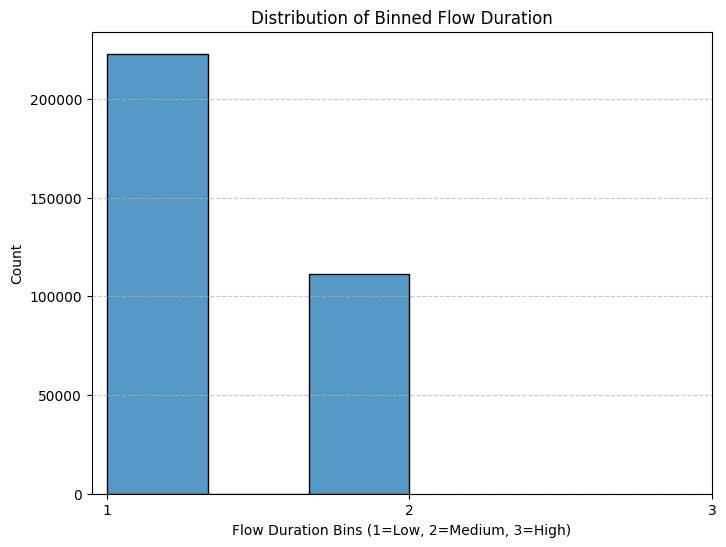

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram for 'Flow Duration_Binned'
plt.figure(figsize=(8, 6))
sns.histplot(df['Flow Duration_Binned'], bins=3, kde=False)
plt.title('Distribution of Binned Flow Duration')
plt.xlabel('Flow Duration Bins (1=Low, 2=Medium, 3=High)')
plt.ylabel('Count')
plt.xticks([1, 2, 3])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Observations: Binned Flow Duration

The histogram for Flow Duration_Binned shows the distribution of network flow durations after being categorized into three bins (low, medium, high). It appears that the majority of flows fall into the 'Low' duration bin, indicating many short-lived connections. This could be typical for certain network traffic patterns, but a very skewed distribution might also suggest a need for further investigation into the characteristics of these short flows.

/tmp/ipykernel_3135/3739446558.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Protocol', data=df, palette='viridis')


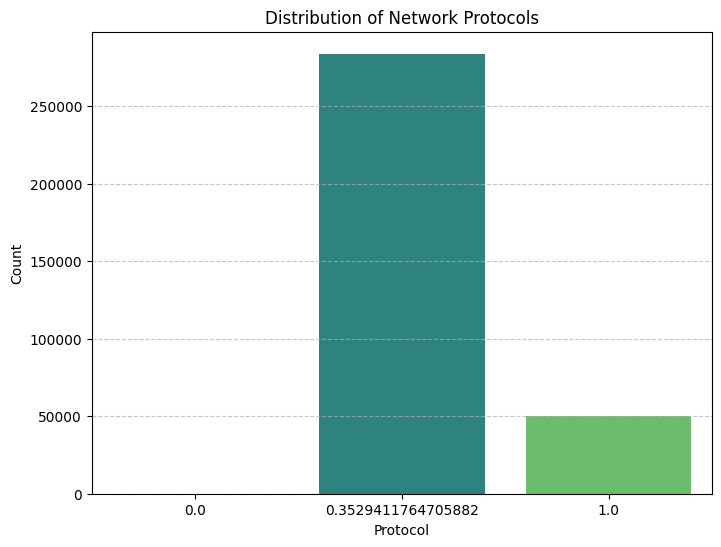

In [13]:
# Bar chart for 'Protocol'
plt.figure(figsize=(8, 6))
sns.countplot(x='Protocol', data=df, palette='viridis')
plt.title('Distribution of Network Protocols')
plt.xlabel('Protocol')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Observations: Network Protocols

The bar chart for Protocol shows the frequency of different network protocols present in the dataset. A dominant protocol (e.g., Protocol 17, which is UDP) suggests that the dataset is heavily comprised of a specific type of traffic. This is consistent with the dataset being named 'UDPLag.csv', implying a focus on UDP-related network activities. Understanding the protocol distribution is crucial for network security analysis, as different protocols have different vulnerabilities and behaviors.

### Observations: Flow Bytes/s Distribution by Attack Label

The box plot for Flow Bytes/s by Label reveals the distribution characteristics of 'Flow Bytes/s' specifically for the 'UDP-lag' attack type. Since the dataset predominantly contains 'UDP-lag' labels, the box plot provides insights into the typical range, median, and potential outliers of byte flow rates associated with this type of network traffic.

*   **Median and Interquartile Range:** The box indicates the central tendency and spread of the data, showing where the majority of 'UDP-lag' traffic's byte rates fall.
*   **Outliers:** Any points extending beyond the 'whiskers' represent potential outliers, which could signify unusually high or low 'Flow Bytes/s' for 'UDP-lag' events. These outliers might be important for identifying extreme attack instances or anomalies.

Further investigation into these outliers might provide valuable information about the intensity or unique characteristics of certain UDP-lag attacks.

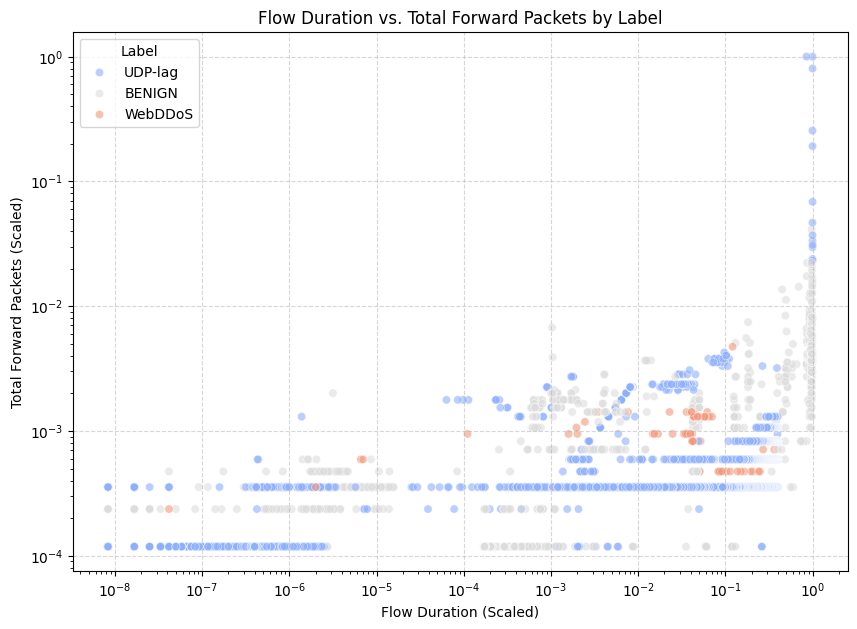

In [14]:
# Scatter plot for 'Flow Duration' vs 'Total Fwd Packets'
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Flow Duration', y='Total Fwd Packets', data=df, hue='Label', palette='coolwarm', alpha=0.6)
plt.title('Flow Duration vs. Total Forward Packets by Label')
plt.xlabel('Flow Duration (Scaled)')
plt.ylabel('Total Forward Packets (Scaled)')
plt.xscale('log') # Use log scale for better visualization if values are highly skewed
plt.yscale('log') # Use log scale for better visualization if values are highly skewed
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---
dhruv kumar(23bce10117)
# Evaluation and Theory

Before evaluating, we need to train a baseline model to generate predictions. Since we imported `LogisticRegression` and `train_test_split` in our initial setup, we will use our PCA-reduced data (`X_reduced`) to train a classification model. We will convert our 'Label' into a binary format (e.g., 'UDP-lag' vs. others) to properly visualize the Confusion Matrix and ROC Curve.



In [15]:
# --- Model Training (Prerequisite for Evaluation) ---
from sklearn.preprocessing import LabelEncoder

# 1. Encode the target variable (Binary classification setup)
# Assuming 'UDP-lag' is the primary class. Adjust if your dataset has a specific 'Normal'/'Benign' class.
df['Target_Binary'] = np.where(df['Label'] == 'UDP-lag', 1, 0)

# 2. Split the PCA-reduced data
X_train, X_test, y_train, y_test = train_test_split(X_reduced, df['Target_Binary'], test_size=0.3, random_state=42)

# 3. Train a Logistic Regression model
clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)

# 4. Generate predictions and probabilities
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("Model Training Complete. Ready for Evaluation.")

Model Training Complete. Ready for Evaluation.


#1. Confusion Matrix and ROC Curve

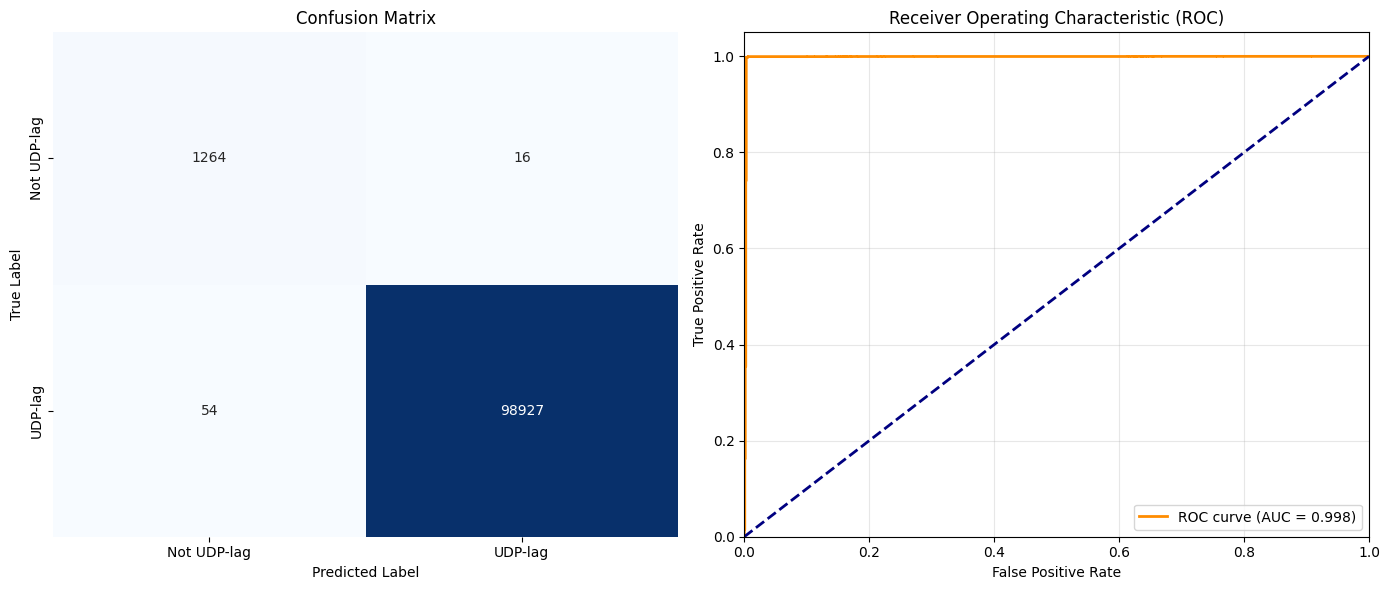


Classification Report:

              precision    recall  f1-score   support

 Not UDP-lag       0.96      0.99      0.97      1280
     UDP-lag       1.00      1.00      1.00     98981

    accuracy                           1.00    100261
   macro avg       0.98      0.99      0.99    100261
weighted avg       1.00      1.00      1.00    100261



In [16]:


# Calculate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Calculate ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Set up the plotting area
plt.figure(figsize=(14, 6))

# Plot 1: Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not UDP-lag', 'UDP-lag'],
            yticklabels=['Not UDP-lag', 'UDP-lag'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Plot 2: ROC Curve
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Not UDP-lag', 'UDP-lag']))

#2. Student's T-Test

In [18]:


feature_to_test = 'Flow Duration'

# Separate the dataset into two groups based on the original label
group_udp = df[df['Label'] == 'UDP-lag'][feature_to_test]
group_other = df[df['Label'] != 'UDP-lag'][feature_to_test]

# Perform independent Welch's t-test (assumes unequal variances)
t_stat, p_value = stats.ttest_ind(group_udp, group_other, equal_var=False)

print(f"--- Student's T-Test Results for '{feature_to_test}' ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.4e}")

print("\n--- Conclusion ---")
if p_value < 0.05:
    print("The p-value is < 0.05. We reject the null hypothesis.")
    print("There is a statistically significant difference in Flow Duration between UDP-lag traffic and other network traffic.")
else:
    print("The p-value is >= 0.05. We fail to reject the null hypothesis.")
    print("There is no statistically significant difference in Flow Duration between the two groups.")

--- Student's T-Test Results for 'Flow Duration' ---
T-statistic: -9.7521
P-value:     3.1284e-22

--- Conclusion ---
The p-value is < 0.05. We reject the null hypothesis.
There is a statistically significant difference in Flow Duration between UDP-lag traffic and other network traffic.


---
## Theory Write-Up

### The Philosophy of Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA), championed by statistician John Tukey, is a philosophy of data analysis that emphasizes looking at data before making assumptions or formulating formal hypotheses. Instead of jumping straight into complex machine learning models, EDA encourages acting as a "data detective."

By using visual tools (like the histograms and scatter plots generated earlier) and quantitative summaries, we allow the data to reveal its underlying structure, distributions, and anomalies. In the context of network security and detecting UDP-lag attacks, EDA is critical. It helps us understand the baseline behavior of normal traffic so that we can accurately identify the deviations caused by malicious activity. Without the intuition built during EDA, a model might fit the data mathematically but fail to capture the true operational realities of the network.

### The Data Science Process
The end-to-end Data Science process is an iterative methodology used to extract actionable insights from raw data. Our workflow in this notebook mirrors the core stages of this process:

1. **Data Understanding & Collection:** Loading the `UDPLag.csv` file and performing an initial inspection using `df.head()` and `df.info()`.
2. **Data Preparation (Processing):** Cleaning the dataset by removing `NaN`s and infinite values. We then scaled the features using Min-Max scaling, discretized continuous variables for better categorization, and reduced the dimensionality (and noise) using PCA.
3. **Exploratory Data Analysis (EDA):** Visualizing the data to uncover trends, such as the dominant network protocols and the relationship between flow duration and packet counts.
4. **Modeling:** Training a machine learning model (Logistic Regression) on our preprocessed, PCA-reduced data to classify network traffic.
5. **Evaluation:** Validating the model's performance using statistical tests (Student's T-test) and classification metrics (Confusion Matrix and ROC Curve) to ensure our solution is both accurate and robust.